In [106]:
import pandas as pd
import numpy as np

student_info = pd.read_csv("studentInfo.csv")
student_registration = pd.read_csv("studentRegistration.csv")
student_assessment = pd.read_csv("studentAssessment.csv")
assessments = pd.read_csv("assessments.csv")
courses = pd.read_csv("courses.csv")
student_vle = pd.read_csv("studentVle.csv")
vle = pd.read_csv("vle.csv")

print("Data loaded successfully.")

Data loaded successfully.


In [14]:
student_info.info()
student_info.shape
student_info.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 4.8 MB


code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [18]:
student_info["imd_band"].unique()

<ArrowStringArray>
['90-100%',  '20-30%',  '30-40%',  '50-60%',  '80-90%',  '70-80%',       nan,
  '60-70%',  '40-50%',   '10-20',   '0-10%']
Length: 11, dtype: str

In [21]:
student_info["imd_band"]=student_info["imd_band"].replace("10-20","10-20%")

In [22]:
student_info["imd_band"].unique()

<ArrowStringArray>
['90-100%',  '20-30%',  '30-40%',  '50-60%',  '80-90%',  '70-80%',       nan,
  '60-70%',  '40-50%',  '10-20%',   '0-10%']
Length: 11, dtype: str

In [23]:
student_info["imd_band"] = student_info["imd_band"].fillna("Unknown")

In [24]:
student_info["imd_band"].unique()

<ArrowStringArray>
['90-100%',  '20-30%',  '30-40%',  '50-60%',  '80-90%',  '70-80%', 'Unknown',
  '60-70%',  '40-50%',  '10-20%',   '0-10%']
Length: 11, dtype: str

In [25]:
student_info.isnull().sum()

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64

In [26]:
student_info["studied_credits"].unique()

array([240,  60, 120,  90, 150, 180, 345, 420, 170,  80,  75, 300, 330,
       210, 270, 360, 135,  70, 225, 585, 325, 130, 195, 105, 655, 165,
       100, 390, 220, 160, 250,  30,  40,  45, 400, 235, 145, 630, 355,
        50, 110, 115,  55,  85, 480, 280, 175,  95, 155, 190, 315, 200,
       140, 540, 310, 370, 205, 215, 255,  65, 430])

In [40]:
student_info.describe()
student_info[student_info["studied_credits"]> 300]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
48,AAA,2013J,141377,M,South West Region,A Level or Equivalent,90-100%,0-35,0,345,N,Withdrawn
57,AAA,2013J,155550,M,London Region,A Level or Equivalent,0-10%,35-55,0,420,N,Pass
273,AAA,2013J,2065691,M,London Region,A Level or Equivalent,30-40%,35-55,0,330,Y,Withdrawn
690,AAA,2014J,2313257,M,London Region,A Level or Equivalent,30-40%,35-55,0,360,N,Withdrawn
865,BBB,2013B,230348,F,East Anglian Region,A Level or Equivalent,0-10%,0-35,2,585,N,Withdrawn
889,BBB,2013B,263499,F,Ireland,Lower Than A Level,40-50%,35-55,0,325,N,Pass
1060,BBB,2013B,395229,F,South Region,Lower Than A Level,40-50%,0-35,1,330,Y,Fail
2778,BBB,2013J,363151,M,North Western Region,Lower Than A Level,10-20%,35-55,0,655,Y,Withdrawn
2869,BBB,2013J,414350,F,East Anglian Region,Lower Than A Level,50-60%,35-55,1,330,Y,Distinction
3210,BBB,2013J,528642,F,Wales,Lower Than A Level,40-50%,0-35,0,390,N,Withdrawn


In [47]:
student_info[student_info["final_result"]=="Withdrawn"].shape[0]

10156

In [48]:
len(student_info[student_info["final_result"]=="Withdrawn"])

10156

In [50]:
student_info[(student_info["studied_credits"]> 300) & (student_info["final_result"]=="Withdrawn")]

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
48,AAA,2013J,141377,M,South West Region,A Level or Equivalent,90-100%,0-35,0,345,N,Withdrawn
273,AAA,2013J,2065691,M,London Region,A Level or Equivalent,30-40%,35-55,0,330,Y,Withdrawn
690,AAA,2014J,2313257,M,London Region,A Level or Equivalent,30-40%,35-55,0,360,N,Withdrawn
865,BBB,2013B,230348,F,East Anglian Region,A Level or Equivalent,0-10%,0-35,2,585,N,Withdrawn
2778,BBB,2013J,363151,M,North Western Region,Lower Than A Level,10-20%,35-55,0,655,Y,Withdrawn
3210,BBB,2013J,528642,F,Wales,Lower Than A Level,40-50%,0-35,0,390,N,Withdrawn
3422,BBB,2013J,565518,F,South West Region,Lower Than A Level,90-100%,35-55,0,330,N,Withdrawn
8690,CCC,2014B,88758,M,North Region,Post Graduate Qualification,Unknown,35-55,0,330,N,Withdrawn
8734,CCC,2014B,153687,F,South Region,A Level or Equivalent,60-70%,35-55,0,400,N,Withdrawn
10477,CCC,2014B,2213982,M,East Anglian Region,Lower Than A Level,20-30%,35-55,0,330,N,Withdrawn


من الجدول  25 صف 
(طلاب عندهم studied_credits > 300 و انسحبوا) 
من أصل الـ 35 صف الكلي اللي عندهم 
studied_credits > 300.
حساب النسبة 25\35 = 71.4 %
و النسية من المجموعه كاملة 31%
هذا فرق ضخم وواضح أكثر من ضعف النسبة العامة! هذا يأكد فعليًا إن فيه علاقة حقيقية بين الحمل الدراسي المرتفع جدًا (300+ ساعة) واحتمالية الانسحاب 

In [52]:
student_info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [58]:
student_info["age_band"].unique()
student_info["gender"].unique()
student_info['highest_education'].unique()
student_info["region"].unique()
student_info["disability"].unique()
print(student_info["age_band"].unique())
print(student_info["gender"].unique())
print(student_info['highest_education'].unique())
print(student_info["region"].unique())
print(student_info["disability"].unique())

<ArrowStringArray>
['55<=', '35-55', '0-35']
Length: 3, dtype: str
<ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
<ArrowStringArray>
[           'HE Qualification',       'A Level or Equivalent',
          'Lower Than A Level', 'Post Graduate Qualification',
             'No Formal quals']
Length: 5, dtype: str
<ArrowStringArray>
[ 'East Anglian Region',             'Scotland', 'North Western Region',
    'South East Region', 'West Midlands Region',                'Wales',
         'North Region',         'South Region',              'Ireland',
    'South West Region', 'East Midlands Region',     'Yorkshire Region',
        'London Region']
Length: 13, dtype: str
<ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str


**Students Registration**

In [59]:
print(student_registration.shape)
student_registration.info()
print(student_registration.isnull().sum())

(32593, 5)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.5 MB
code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64


In [60]:
student_registration["date_unregistration"]

0          NaN
1          NaN
2         12.0
3          NaN
4          NaN
         ...  
32588      NaN
32589      NaN
32590      NaN
32591    101.0
32592      NaN
Name: date_unregistration, Length: 32593, dtype: float64

In [61]:
student_registration[student_registration["date_registration"].isnull()]

,code_module,code_presentation,id_student,date_registration,date_unregistration
2344,BBB,2013B,630346,NaN,NaN
2538,BBB,2013J,57369,NaN,-1.0
2759,BBB,2013J,342678,NaN,-33.0
5356,BBB,2014B,582496,NaN,-126.0
5490,BBB,2014B,607646,NaN,-38.0
5573,BBB,2014B,614270,NaN,-142.0
6295,BBB,2014B,2409808,NaN,-109.0
6305,BBB,2014B,2439442,NaN,-149.0
8307,BBB,2014J,694001,NaN,-36.0
8975,CCC,2014B,394791,NaN,-61.0


In [62]:
missing_reg = student_registration[student_registration["date_registration"].isnull()]
missing_reg["date_unregistration"].notnull().sum()

np.int64(39)

## Data Cleaning Note — `studentRegistration.csv`

**Shape:** 32,593 rows × 5 columns — matches `studentInfo` row count exactly.

### Missing Values Analysis

**1. `date_unregistration`** — 22,521 missing (69%)
- Not a data quality issue — this is **structurally missing (MNAR)**: students who never withdrew simply have no unregistration date.
- Validation: non-null count (10,072) closely matches the number of students with `final_result == "Withdrawn"` in `studentInfo` (10,156).
- **Decision:** Left as NaN — the missingness itself is meaningful (= student did not withdraw).

**2. `date_registration`** — 45 missing (0.14%)
- Further investigation: **39 of 45 rows (87%)** have a non-null `date_unregistration`, meaning these students *did* withdraw — but their registration date was never logged, likely due to withdrawing very soon after (or during) registration.
- The remaining 6 rows are missing in both columns (full ambiguity).
- **Decision:** Left as NaN — the pattern is explainable (early withdrawal), not random corruption.

### Conclusion
No imputation or row removal needed for `studentRegistration`. All missing values are explainable by the registration/withdrawal lifecycle rather than data entry errors.

## courses

In [63]:
print(courses.shape)
courses.info()
print(courses.isnull().sum())

(22, 3)
<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 836.0 bytes
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64


In [64]:
courses["module_presentation_length"].unique()

array([268, 269, 262, 240, 234, 241, 261])

## assessments

In [65]:
print(assessments.shape)
assessments.info()
print(assessments.isnull().sum())

(206, 6)
<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 12.0 KB
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64


In [66]:
assessments[assessments["date"].isnull()]

,code_module,code_presentation,id_assessment,assessment_type,date,weight
5,AAA,2013J,1757,Exam,NaN,100.0
11,AAA,2014J,1763,Exam,NaN,100.0
23,BBB,2013B,14990,Exam,NaN,100.0
35,BBB,2013J,15002,Exam,NaN,100.0
47,BBB,2014B,15014,Exam,NaN,100.0
53,BBB,2014J,15025,Exam,NaN,100.0
62,CCC,2014B,24290,Exam,NaN,100.0
63,CCC,2014B,40087,Exam,NaN,100.0
72,CCC,2014J,24299,Exam,NaN,100.0
73,CCC,2014J,40088,Exam,NaN,100.0


In [67]:
assessments[assessments["assessment_type"] == "Exam"]

,code_module,code_presentation,id_assessment,assessment_type,date,weight
5,AAA,2013J,1757,Exam,NaN,100.0
11,AAA,2014J,1763,Exam,NaN,100.0
23,BBB,2013B,14990,Exam,NaN,100.0
35,BBB,2013J,15002,Exam,NaN,100.0
47,BBB,2014B,15014,Exam,NaN,100.0
53,BBB,2014J,15025,Exam,NaN,100.0
62,CCC,2014B,24290,Exam,NaN,100.0
63,CCC,2014B,40087,Exam,NaN,100.0
72,CCC,2014J,24299,Exam,NaN,100.0
73,CCC,2014J,40088,Exam,NaN,100.0


## Data Cleaning Note — `assessments.csv`

**Shape:** 206 rows × 6 columns, no type issues.

**Missing values — `date`:** 11 of 206 (5.3%), all type `Exam`, limited to specific modules (AAA, BBB, CCC, DDD-2014J). Most other exams *do* have a date, so this isn't a general "exams have no date" pattern — just a documentation gap for a few course offerings.

**Decision:** Left as NaN. Too few and too specific to justify imputing a fake date. Can use `module_presentation_length` from `courses.csv` as a proxy later if needed (exams typically fall near the end of the presentation).

## studentAssessment

In [68]:
print(student_assessment.shape)
student_assessment.info()
print(student_assessment.isnull().sum())

(173912, 5)
<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64


In [69]:
student_assessment[student_assessment["score"].isnull()]["is_banked"].value_counts()

is_banked
0    172
1      1
Name: count, dtype: int64

In [81]:
student_assessment[student_assessment["score"].isnull()]

,id_assessment,id_student,date_submitted,is_banked,score
215,1752,721259,22,0,NaN
937,1754,260355,127,0,NaN
2364,1760,2606802,180,0,NaN
3358,14984,186780,77,0,NaN
3914,14984,531205,26,0,NaN
...,...,...,...,...,...
148929,34903,582670,241,0,NaN
159251,37415,610738,87,0,NaN
166390,37427,631786,221,0,NaN
169725,37435,648110,62,0,NaN


In [82]:
student_assessment = student_assessment.dropna(subset=["score"])

In [83]:
print(student_assessment.shape)
print(student_assessment.isnull().sum())

(173739, 5)
id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64


## vle

In [84]:
print(vle.shape)
vle.info()
print(vle.isnull().sum())

(6364, 6)
<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   str    
 2   code_presentation  6364 non-null   str    
 3   activity_type      6364 non-null   str    
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 393.3 KB
id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64


In [85]:
vle[vle["week_from"].isnull()]["activity_type"].value_counts()

activity_type
resource          2512
subpage            920
oucontent          615
url                534
forumng            194
quiz               114
oucollaborate       82
page                69
ouwiki              43
dataplus            26
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
questionnaire       19
dualpane            15
htmlactivity         4
sharedsubpage        3
folder               2
repeatactivity       1
Name: count, dtype: int64

In [86]:
vle["activity_type"].value_counts()

activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64

## Data Cleaning Note — `vle.csv`

**Shape:** 6,364 rows × 6 columns, no type issues. `id_site` is a unique identifier (not an analytical feature).

**Missing values — `week_from` / `week_to`:** 5,243 of 6,364 (82%) missing in both columns together.

Checked for a pattern by `activity_type`: missingness is high (60–100%) across almost every activity type (resource, subpage, forumng, quiz, oucollaborate, etc.), not concentrated in one category. This supports the interpretation that most activities are available for the **entire course duration** with no fixed time window — the missing values represent "no restriction," not missing data. Activities with lower missingness (e.g., `questionnaire` at 31%) are more likely tied to a specific window.

**Decision:** Left as NaN. If a weekly availability check is needed later, missing `week_from`/`week_to` can be treated as "available throughout the presentation."

## studentVle

In [88]:
print(student_vle.shape)
student_vle.info()
print(student_vle.isnull().sum())

(10655280, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 569.1 MB
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


In [90]:
print(student_vle["date"].min())
print(student_vle["date"].max())

-25
269


## Merge

In [91]:
df = student_info.merge(
    student_registration,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

print(df.shape)

(32593, 14)


In [92]:
assessment_merged = student_assessment.merge(
    assessments,
    on="id_assessment",
    how="left"
)
print(assessment_merged.shape)

(173739, 10)


In [93]:
assessment_summary = assessment_merged.groupby(
    ["id_student", "code_module", "code_presentation"]
).agg({
    "score": "mean",
    "id_assessment": "count"
}).reset_index()

print(assessment_summary.shape)
assessment_summary.head()

(25820, 5)


,id_student,code_module,code_presentation,score,id_assessment
0,6516,AAA,2014J,61.800000,5
1,8462,DDD,2013J,87.666667,3
2,8462,DDD,2014J,86.500000,4
3,11391,AAA,2013J,82.000000,5
4,23629,BBB,2013B,82.500000,4


In [94]:
assessment_summary = assessment_summary.rename(columns={
    "score": "avg_score",
    "id_assessment": "num_assessments_submitted"
})

In [95]:
assessment_summary.head()

,id_student,code_module,code_presentation,avg_score,num_assessments_submitted
0,6516,AAA,2014J,61.800000,5
1,8462,DDD,2013J,87.666667,3
2,8462,DDD,2014J,86.500000,4
3,11391,AAA,2013J,82.000000,5
4,23629,BBB,2013B,82.500000,4


In [96]:
vle_merged = student_vle.merge(
    vle,
    on="id_site",
    how="left"
)
print(vle_merged.shape)

(10655280, 11)


In [97]:
vle_summary = vle_merged.groupby(
    ["id_student", "code_module_x", "code_presentation_x"]
).agg({
    "sum_click": "sum",
    "date": "nunique"
}).reset_index()

print(vle_summary.shape)
vle_summary.head()

(29228, 5)


,id_student,code_module_x,code_presentation_x,sum_click,date
0,6516,AAA,2014J,2791,159
1,8462,DDD,2013J,646,56
2,8462,DDD,2014J,10,1
3,11391,AAA,2013J,934,40
4,23629,BBB,2013B,161,16


In [98]:
vle_summary = vle_summary.rename(columns={
    "code_module_x": "code_module",
    "code_presentation_x": "code_presentation",
    "sum_click": "total_clicks",
    "date": "active_days"
})

In [99]:
vle_summary

,id_student,code_module,code_presentation,total_clicks,active_days
0,6516,AAA,2014J,2791,159
1,8462,DDD,2013J,646,56
2,8462,DDD,2014J,10,1
3,11391,AAA,2013J,934,40
4,23629,BBB,2013B,161,16
...,...,...,...,...,...
29223,2698257,AAA,2013J,758,69
29224,2698535,CCC,2014B,786,34
29225,2698535,EEE,2013J,3455,110
29226,2698577,BBB,2014J,717,37


In [100]:
df = df.merge(
    assessment_summary,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

df = df.merge(
    vle_summary,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

print(df.shape)
df.head()

(32593, 18)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,avg_score,num_assessments_submitted,total_clicks,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,82.0,5.0,934.0,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN,66.4,5.0,1435.0,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,-92.0,12.0,NaN,NaN,281.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,NaN,76.0,5.0,2158.0,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,NaN,54.4,5.0,1034.0,70.0


## Final Merge Summary

Merged 5 cleaned tables into a single student-level dataset, keyed on `id_student` + `code_module` + `code_presentation`.

**Merge order:**
1. `studentInfo` (base) ← `studentRegistration` (3-column key)
2. `studentAssessment` ← `assessments` (on `id_assessment`), then grouped to one row per student/module/presentation (`avg_score`, `num_assessments_submitted`)
3. `studentVle` ← `vle` (on `id_site`), then grouped the same way (`total_clicks`, `active_days`)
4. Base table ← assessment summary ← VLE summary (all `how="left"`)

**Result:** 32,593 rows × 18 columns — row count unchanged from the original `studentInfo`, confirming no duplication or data loss.

### New missing values introduced by the merge
`avg_score`, `num_assessments_submitted`, `total_clicks`, `active_days` are NaN for students who withdrew/never engaged before submitting any assessment or visiting the site. 

**Decision:** Left as NaN for now — these zeros would be misleading if computed (e.g., averaging in a 0 score for a student who never submitted anything would distort the true average). This will be revisited explicitly at the feature engineering stage, where NaN may be converted to 0 (or a separate `submitted_any_assessment` flag) once the model actually needs numeric input.

### Conclusion
Data cleaning and merging stage complete. Dataset is ready for feature engineering.

In [101]:
df["id_student"].value_counts().value_counts()

count
1    25247
2     3293
3      221
4       23
5        1
Name: count, dtype: int64

In [102]:
df["at_risk"] = df["final_result"].isin(["Fail", "Withdrawn"]).astype(int)
print(df["at_risk"].value_counts())

at_risk
1    17208
0    15385
Name: count, dtype: int64


In [103]:
for col in ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]:
    print(col, "-", df[col].nunique(), "unique values")

gender - 2 unique values
region - 13 unique values
highest_education - 5 unique values
imd_band - 11 unique values
age_band - 3 unique values
disability - 2 unique values


In [104]:
age_order = ["0-35", "35-55", "55<="]
df["age_band_encoded"] = pd.Categorical(df["age_band"], categories=age_order, ordered=True).codes
print(df[["age_band", "age_band_encoded"]].drop_duplicates())

  age_band  age_band_encoded
0     55<=                 2
1    35-55                 1
4     0-35                 0


In [107]:
# highest_education: ordinal encoding (lowest to highest qualification)
education_order = [
    "No Formal quals",
    "Lower Than A Level",
    "A Level or Equivalent",
    "HE Qualification",
    "Post Graduate Qualification"
]
df["highest_education_encoded"] = pd.Categorical(
    df["highest_education"], categories=education_order, ordered=True
).codes

print(df[["highest_education", "highest_education_encoded"]].drop_duplicates())

# imd_band: ordinal encoding (lowest to highest deprivation band)
imd_order = [
    "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
    "50-60%", "60-70%", "70-80%", "80-90%", "90-100%",
    "Unknown"
]
df["imd_band_encoded"] = pd.Categorical(
    df["imd_band"], categories=imd_order, ordered=True
).codes

# Fix: "Unknown" should be NaN, not treated as the highest band (10)
df.loc[df["imd_band"] == "Unknown", "imd_band_encoded"] = np.nan

print(df[["imd_band", "imd_band_encoded"]].drop_duplicates())

                highest_education  highest_education_encoded
0                HE Qualification                          3
2           A Level or Equivalent                          2
4              Lower Than A Level                          1
9     Post Graduate Qualification                          4
1083              No Formal quals                          0
   imd_band  imd_band_encoded
0   90-100%               9.0
1    20-30%               2.0
2    30-40%               3.0
3    50-60%               5.0
5    80-90%               8.0
8    70-80%               7.0
9   Unknown               NaN
12   60-70%               6.0
14   40-50%               4.0
18   10-20%               1.0
21    0-10%               0.0


In [108]:
df = pd.get_dummies(df, columns=["gender", "region", "disability"], drop_first=True)

In [109]:
df.columns.tolist()

['code_module',
 'code_presentation',
 'id_student',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'final_result',
 'date_registration',
 'date_unregistration',
 'avg_score',
 'num_assessments_submitted',
 'total_clicks',
 'active_days',
 'at_risk',
 'age_band_encoded',
 'highest_education_encoded',
 'imd_band_encoded',
 'gender_M',
 'region_East Midlands Region',
 'region_Ireland',
 'region_London Region',
 'region_North Region',
 'region_North Western Region',
 'region_Scotland',
 'region_South East Region',
 'region_South Region',
 'region_South West Region',
 'region_Wales',
 'region_West Midlands Region',
 'region_Yorkshire Region',
 'disability_Y']

## Feature Engineering Note — Encoding

**Target variable:** `final_result` (4 classes: Pass, Fail, Withdrawn, Distinction) simplified to a binary `at_risk` flag:
- `at_risk = 1` → Fail or Withdrawn (17,208 students, ~53%)
- `at_risk = 0` → Pass or Distinction (15,385 students, ~47%)

This matches the project's own framing ("flag students at risk of failing or withdrawing") and produces a near-balanced target, simplifying later modeling.

**Ordinal encoding** (categories have a natural order — mapped to integers preserving that order):
- `age_band` → 0-35=0, 35-55=1, 55<==2
- `highest_education` → No Formal quals=0 ... Post Graduate Qualification=4
- `imd_band` → 0-10%=0 ... 90-100%=9. `"Unknown"` mapped to `NaN` (not 10) — it represents missing information, not the highest deprivation band, so including it in the numeric sequence would have misrepresented it to the model.

**One-hot encoding** (`pd.get_dummies`, `drop_first=True`) for nominal categories with no natural order: `gender`, `region`, `disability`. The dropped reference category for `region` is `East Anglian Region` (all-zero row = that region).

**Note:** Original text columns (`highest_education`, `imd_band`, `age_band`, `final_result`) are kept alongside their encoded versions for now, for visual verification — to be dropped in a final cleanup step just before model training.

### Next step
Rebuild `total_clicks` / `active_days` as time-windowed features (first 4 weeks, first 8 weeks, etc.) from `vle_merged`, to support early-detection analysis (Business Question 2).

In [110]:
vle_merged["week_number"] = (vle_merged["date"] // 7) + 1

In [111]:
print(vle_merged["week_number"].min(), vle_merged["week_number"].max())

-3 39


In [112]:
early_activity = vle_merged[vle_merged["week_number"] <= 4]

early_summary = early_activity.groupby(
    ["id_student", "code_module_x", "code_presentation_x"]
).agg({
    "sum_click": "sum",
    "date": "nunique"
}).reset_index()

early_summary = early_summary.rename(columns={
    "code_module_x": "code_module",
    "code_presentation_x": "code_presentation",
    "sum_click": "clicks_week4",
    "date": "active_days_week4"
})

print(early_summary.shape)
early_summary.head()

(28774, 5)


,id_student,code_module,code_presentation,clicks_week4,active_days_week4
0,6516,AAA,2014J,799,27
1,8462,DDD,2013J,340,19
2,8462,DDD,2014J,10,1
3,11391,AAA,2013J,401,8
4,23629,BBB,2013B,53,6


In [113]:
early_activity_8 = vle_merged[vle_merged["week_number"] <= 8]

early_summary_8 = early_activity_8.groupby(
    ["id_student", "code_module_x", "code_presentation_x"]
).agg({
    "sum_click": "sum",
    "date": "nunique"
}).reset_index()

early_summary_8 = early_summary_8.rename(columns={
    "code_module_x": "code_module",
    "code_presentation_x": "code_presentation",
    "sum_click": "clicks_week8",
    "date": "active_days_week8"
})

print(early_summary_8.shape)
early_summary_8.head()

(29078, 5)


,id_student,code_module,code_presentation,clicks_week8,active_days_week8
0,6516,AAA,2014J,1005,45
1,8462,DDD,2013J,517,36
2,8462,DDD,2014J,10,1
3,11391,AAA,2013J,529,18
4,23629,BBB,2013B,84,10


In [114]:
df = df.merge(
    early_summary,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

df = df.merge(
    early_summary_8,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

print(df.shape)

(32593, 37)


In [115]:
cols_to_fill = [
    "avg_score", "num_assessments_submitted",
    "total_clicks", "active_days",
    "clicks_week4", "active_days_week4",
    "clicks_week8", "active_days_week8"
]

df[cols_to_fill] = df[cols_to_fill].fillna(0)

In [ ]:
df_final = df.drop(columns=[
    "id_student",           # معرّف، مو ميزة
    "highest_education",    # نسخة نصية (عندنا المرمزة)
    "imd_band",              # نسخة نصية
    "age_band",               # نسخة نصية
    "final_result",          # النص الأصلي (عندنا at_risk)
    "date_unregistration"   
])

In [117]:
df_final.to_csv("oulad_final_features.csv", index=False)
print(df_final.shape)
print("تم الحفظ بنجاح")

(32593, 31)
تم الحفظ بنجاح


In [118]:
from sklearn.model_selection import GroupKFold, train_test_split

feature_cols = [col for col in df_final.columns if col not in [
    "code_module", "code_presentation", "at_risk"
]]

X = df_final[feature_cols]
y = df_final["at_risk"]
groups = df["id_student"]  # احتاجها من df الأصلي (فيها id_student)

print(X.shape, y.shape)

(32593, 28) (32593,)


In [119]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(X_train.shape, X_test.shape)

(26122, 28) (6471, 28)


In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_imputed, y_train)

y_pred = log_reg.predict(X_test_imputed)

c:\Users\Ragha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\Ragha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

c:\Users\Ragha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [122]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      3073
           1       0.92      0.88      0.90      3398

    accuracy                           0.90      6471
   macro avg       0.90      0.90      0.90      6471
weighted avg       0.90      0.90      0.90      6471

[[2829  244]
 [ 406 2992]]


In [123]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)  # XGBoost يتعامل مع NaN مباشرة، ما يحتاج Imputer أو Scaler!

y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      3073
           1       0.95      0.88      0.92      3398

    accuracy                           0.92      6471
   macro avg       0.92      0.92      0.91      6471
weighted avg       0.92      0.92      0.92      6471



In [125]:
%pip install shap

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.8/41.9 MB 1.9 MB/s eta 0:00:22
   - -------------------------------------- 1.0/41.9 MB 1.9 MB/s eta 0:00:22
   - -------------------------------------- 1.6/41.9 MB 1.9 MB/s eta 0:00:21
   - -------------------------------------- 1.8/41.9 MB 2.0 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/41.9 MB 2.0 MB/s eta 0:00:20
   -- ------------------------------------- 2.9/41.9 MB 2.0 MB/s eta 0:00:20
   --- ------------------------------------ 3.1/41.9 MB 2.0 MB/s eta 0:00:20
   --- ------------------------------------ 3.7/41.9 MB 1.9 MB/s eta 0:00:20
   --- ------------------------------------ 3.9/41.9 MB 1.9 MB/s eta 0:00:21
   ---- -----------------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\Ragha\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


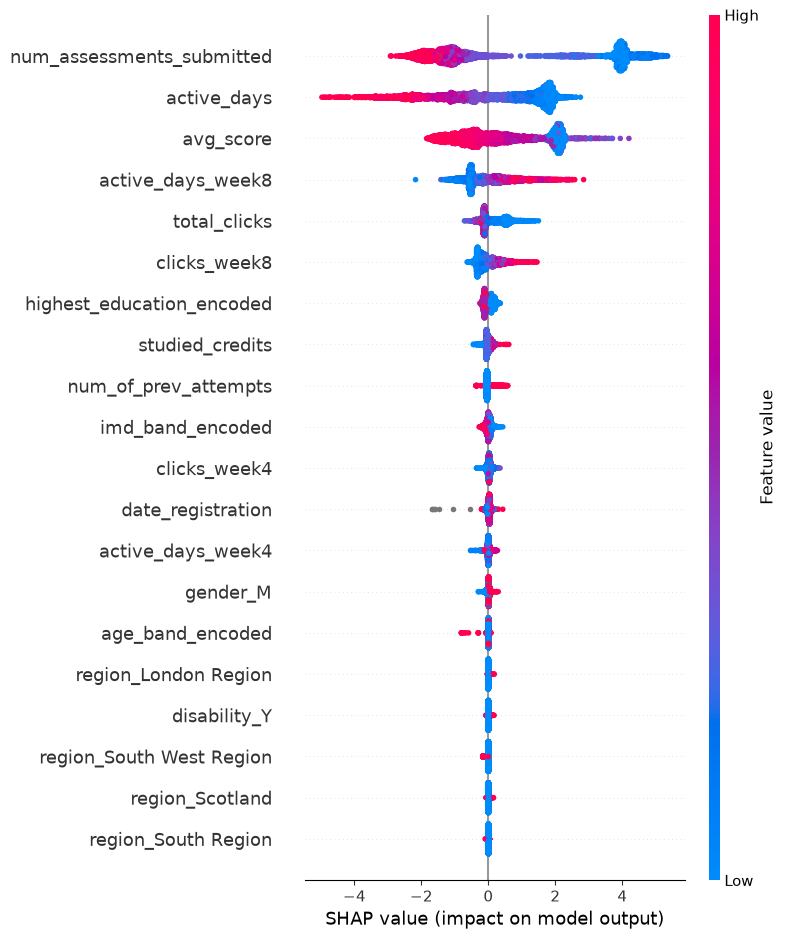

In [126]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)